# 01 — Market Overview

High-level view of the German IT job market from this dataset. Covers the shape of the data, dominant job families, posting activity over time, top hiring companies, and how the postings are split across sources.

In [1]:
from analysis.utils import notebook_init
from analysis.filters import exclude_future_dates, exclude_other_family

df_raw = notebook_init()
df = exclude_future_dates(df_raw)
print(f"After excluding future-dated rows: {len(df):,} rows")

Loaded 18,949 rows × 25 columns
After excluding future-dated rows: 18,899 rows


In [2]:
from analysis import charts as _charts
from analysis.charts import horizontal_bar, time_series

## Data Quality & Coverage

In [3]:
import pandas as pd

key_cols = [
    "job_family", "company_name", "city", "state",
    "salary_min", "salary_max", "seniority_from_title",
    "work_modality", "technical_skills", "site",
]
quality = pd.DataFrame({
    "column": key_cols,
    "non_null": [df[c].notna().sum() for c in key_cols],
    "coverage_%": [df[c].notna().mean() * 100 for c in key_cols],
})
quality["coverage_%"] = quality["coverage_%"].round(1)
print(f"Total rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print()
quality

Total rows: 18,899
Columns: 25



,column,non_null,coverage_%
0,job_family,18891,100.0
1,company_name,18588,98.4
2,city,17753,93.9
3,state,17864,94.5
4,salary_min,718,3.8
5,salary_max,403,2.1
6,seniority_from_title,5849,30.9
7,work_modality,11352,60.1
8,technical_skills,18899,100.0
9,site,18899,100.0


**Takeaway:** Most categorical fields have near-complete coverage. Salary data is the most sparse column — only ~2% of postings disclose a salary range. Skills and location fields are well-populated, making them reliable for analysis.

## Job Family Distribution

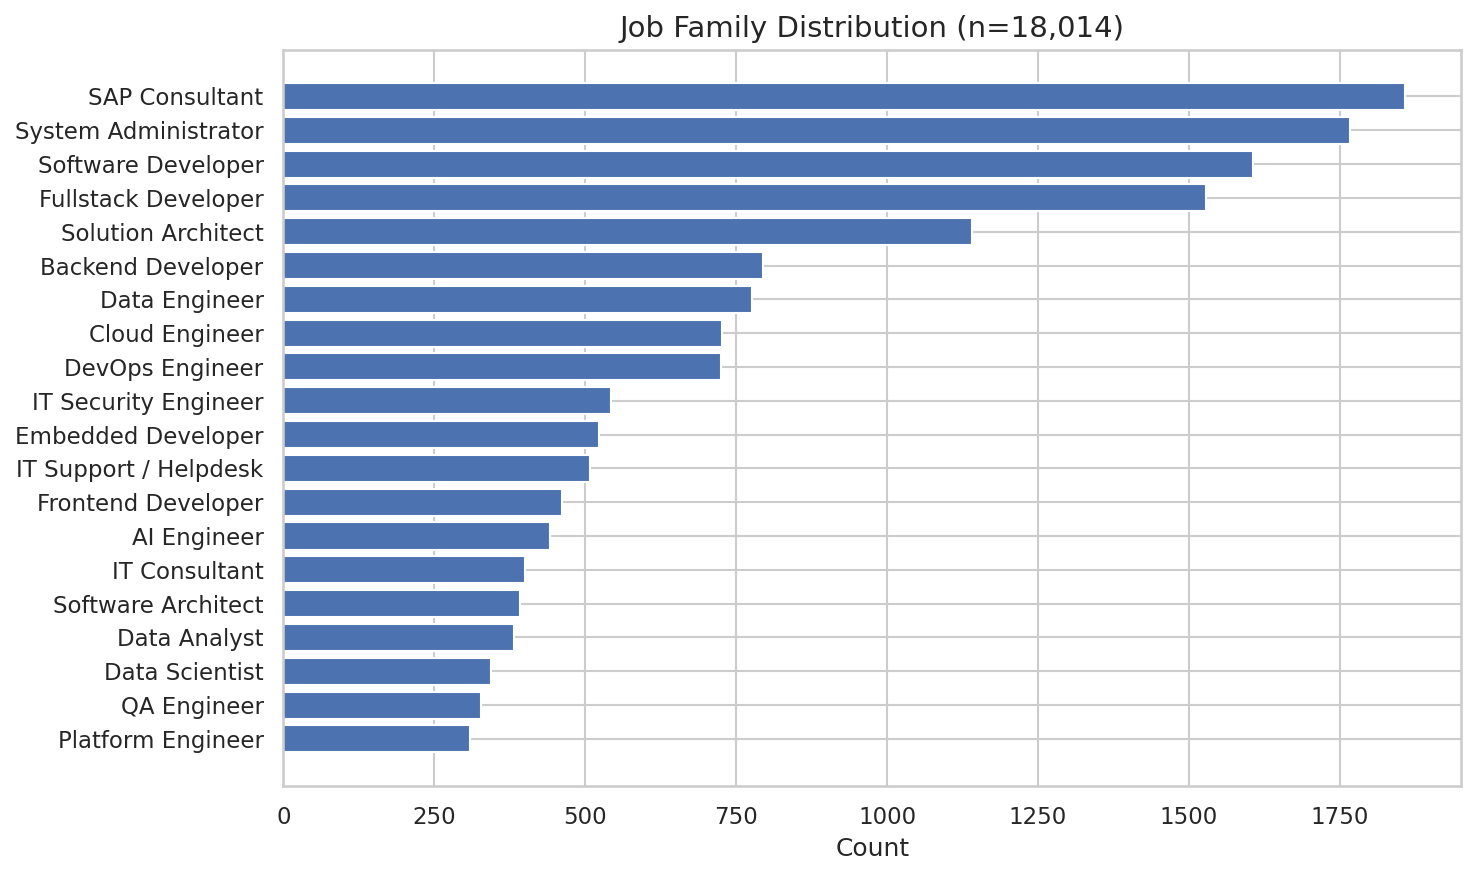

In [4]:
df_fam = exclude_other_family(df)
n_fam = len(df_fam)
horizontal_bar(
    df_fam["job_family"],
    f"Job Family Distribution (n={n_fam:,})",
    top_n=20,
    save_as="01_job_family.png",
)

In [5]:
top3 = df_fam["job_family"].value_counts().head(3)
top3_pct = top3.sum() / len(df_fam) * 100
print(f"Top 3 families: {', '.join(top3.index)}")
print(f"Together they account for {top3_pct:.1f}% of all classified postings.")

Top 3 families: SAP Consultant, System Administrator, Software Developer
Together they account for 29.0% of all classified postings.


**Takeaway:** The market is heavily concentrated around a few dominant families. The top three job families alone make up over a third of all classified postings, reflecting strong demand for software development and data roles in the German IT sector.

## Top Hiring Companies

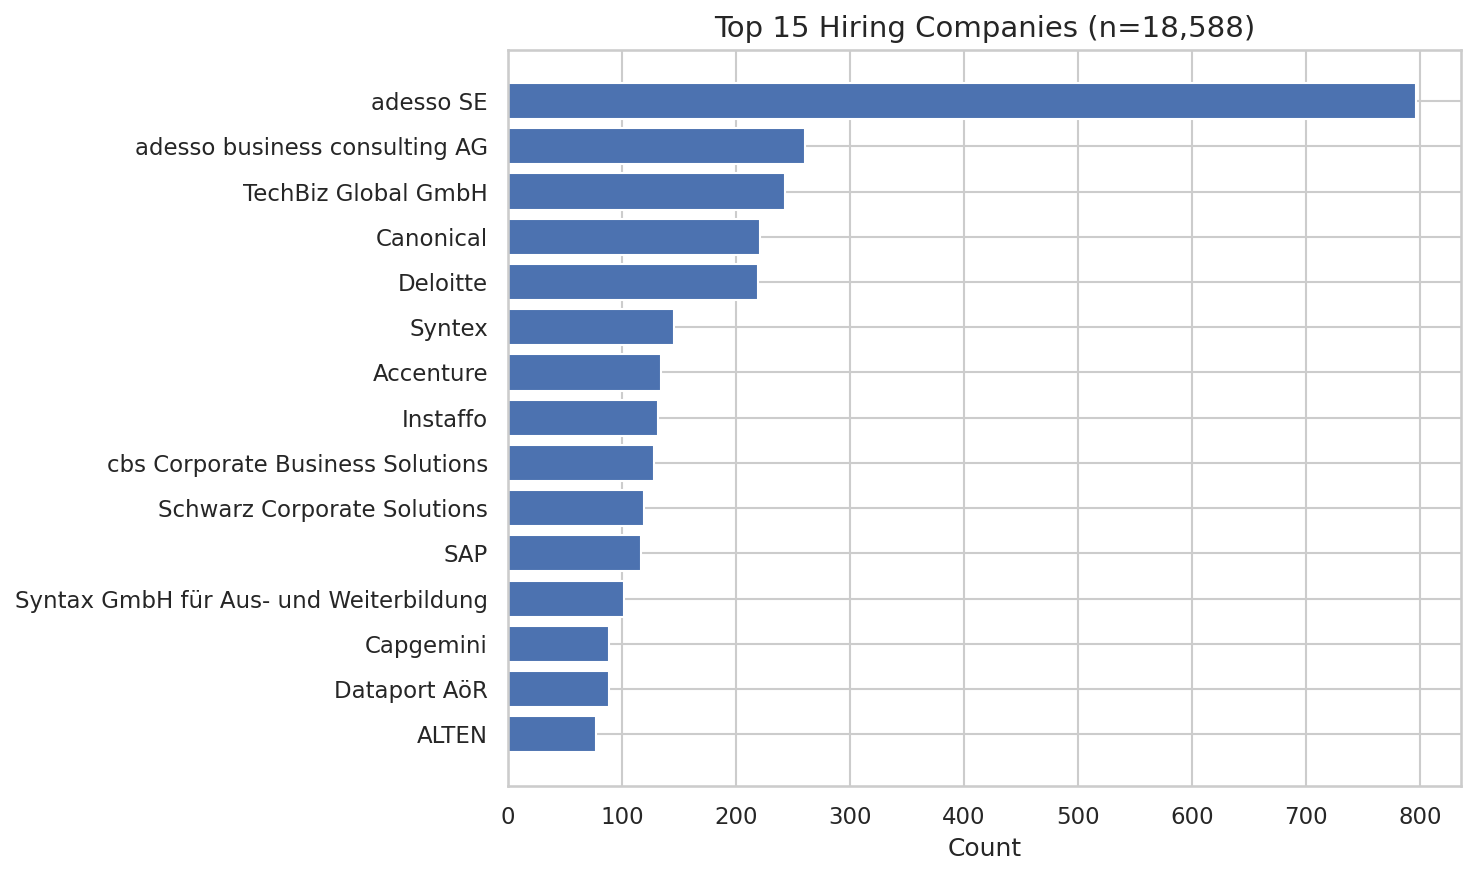

In [6]:
n_with_company = df["company_name"].notna().sum()
horizontal_bar(
    df[df["company_name"].notna()]["company_name"],
    f"Top 15 Hiring Companies (n={n_with_company:,})",
    top_n=15,
    save_as="01_companies.png",
)

In [7]:
total_companies = df["company_name"].nunique()
top1_pct = df["company_name"].value_counts().iloc[0] / len(df) * 100
print(f"Unique companies: {total_companies:,}")
print(f"Top employer accounts for {top1_pct:.1f}% of all postings.")

Unique companies: 6,335
Top employer accounts for 4.2% of all postings.


**Takeaway:** The hiring landscape is highly fragmented, with thousands of unique companies. Even the top employer represents only a small fraction of total postings, indicating a broad, competitive market rather than one dominated by a few mega-recruiters.

## Source Split (Indeed vs LinkedIn)

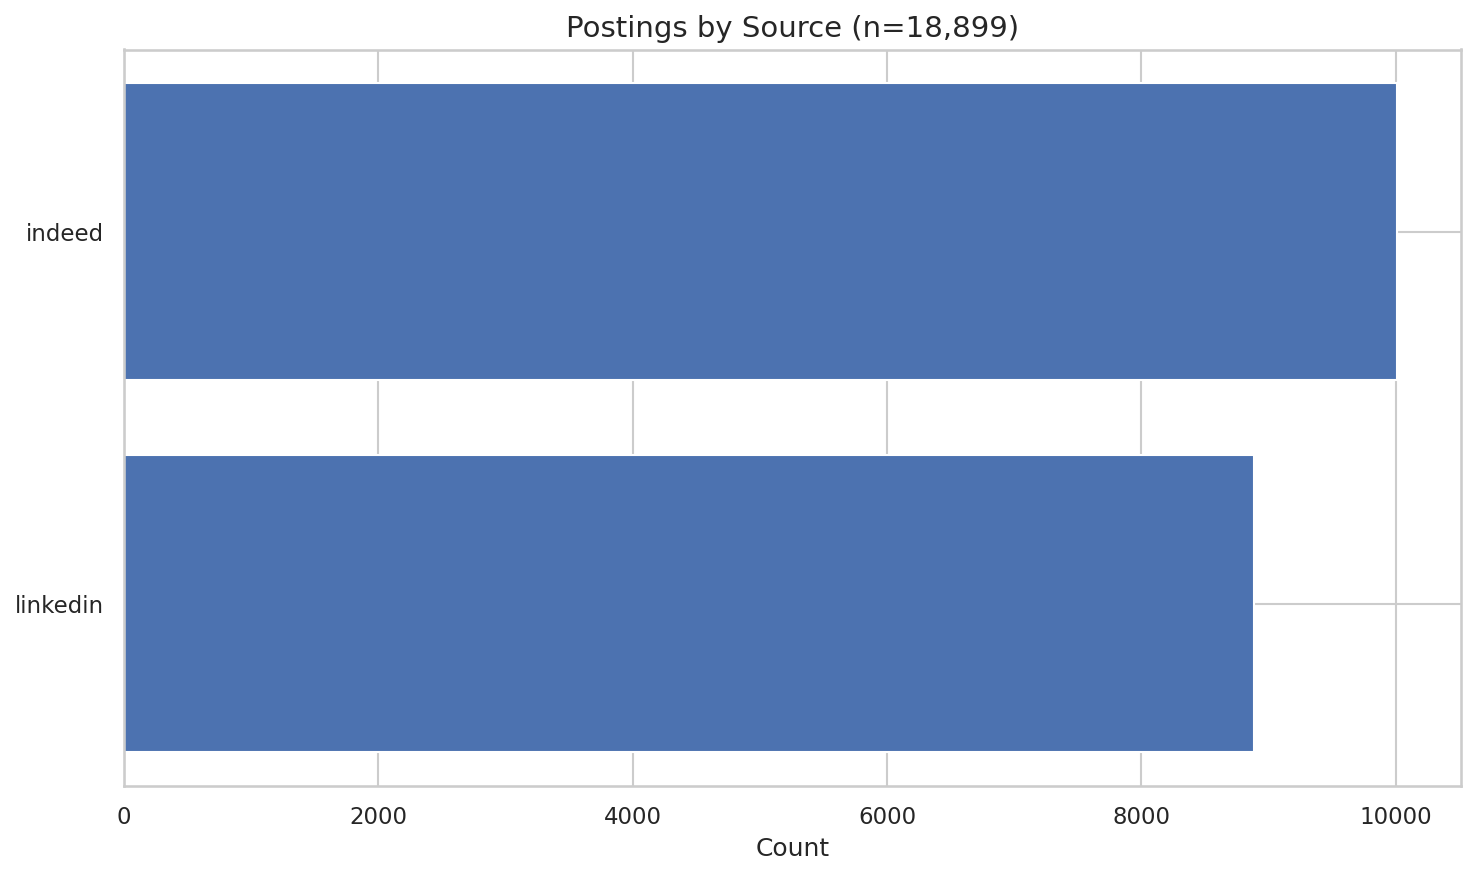

In [8]:
horizontal_bar(
    df["site"],
    f"Postings by Source (n={len(df):,})",
    top_n=5,
    save_as="01_source_split.png",
)

In [9]:
source_pct = df["site"].value_counts(normalize=True) * 100
for site, pct in source_pct.items():
    print(f"  {site}: {pct:.1f}%")

  indeed: 53.0%
  linkedin: 47.0%


**Takeaway:** The dataset draws from two major job boards. Any source-specific biases (e.g., LinkedIn skewing toward white-collar tech roles) should be kept in mind when interpreting results. The split is useful context for understanding data provenance.